# ICU Energy Analysis v3 — MIMIC-IV & eICU
## Research: ICU Monitor Sustainability Research
**Author:** Konstantinos Dinos Kritsis  
**Date:** May 2026

In this notebook I address all the corrections and improvements raised by 
my supervisor Timo following his review of my v2 analysis. Specifically:

1. I removed the arbitrary 5% threshold from the time-of-day histogram 
   since it had no literature source to justify it
2. I normalised wasted energy to kWh per stay in the ICU unit chart 
   so that units with more stays are not unfairly penalised
3. I split the energy comparison chart into two separate figures — 
   one for MIMIC-IV and one for eICU
4. I removed careunit_code from the K-means clustering features — 
   I now cluster purely on waste patterns so that any association 
   with care unit type becomes a finding rather than an assumption
5. I added CO2 figures inside the bar labels in the cluster savings chart 
   and added a second chart showing waste per stay

In [2]:
# I import all the libraries I need for this analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")

All libraries loaded successfully!


## My Constants — Power Figures and CO2 Factors

### Philips X3+M750 — the only peer reviewed measured monitor
I use the values physically measured by Drinhaus et al. (2023) in a real ICU:
- Operating: 34.8W | Standby: 30.5W | Standby ratio: 87.6%
- Source: https://pmc.ncbi.nlm.nih.gov/articles/PMC10119198/

### GE CARESCAPE ONE — I conduct a sensitivity analysis
Since no peer reviewed power measurement exists for GE devices I use 
three assumptions to represent the uncertainty:
- Optimistic: 20W | Moderate: 40W | Conservative: 60W (maximum dock output)
- Source: GE Healthcare CARESCAPE ONE official datasheet (2023)

### CO2 Emission Factors — EPA eGRID 2023
I updated my CO2 factors to US-specific figures following supervisor feedback:
- MIMIC-IV: 0.245 kg/kWh — NEWE subregion (Massachusetts)
- eICU: 0.348 kg/kWh — US national average
- Source: https://www.epa.gov/egrid/summary-data

In [3]:
# I define all power and CO2 constants I will use throughout this notebook

# Philips X3+M750 — physically measured by Drinhaus et al. (2023)
PHILIPS_OPERATING = 0.0348   # kW — 34.8W operating
PHILIPS_STANDBY   = 0.0305   # kW — 30.5W standby
PHILIPS_RATIO     = PHILIPS_STANDBY / PHILIPS_OPERATING  # 87.6% standby ratio

# GE CARESCAPE ONE — I use three assumptions since no measured value exists
GE_OPTIMISTIC   = 0.0200   # kW — 20W optimistic estimate
GE_MODERATE     = 0.0400   # kW — 40W moderate estimate
GE_CONSERVATIVE = 0.0600   # kW — 60W maximum rated dock output

# I apply the Philips standby ratio to GE as the best available approximation
GE_STANDBY_OPT  = GE_OPTIMISTIC   * PHILIPS_RATIO
GE_STANDBY_MOD  = GE_MODERATE     * PHILIPS_RATIO
GE_STANDBY_CON  = GE_CONSERVATIVE * PHILIPS_RATIO

# CO2 emission factors — EPA eGRID 2023
# I use dataset-specific factors as recommended by my supervisor
CO2_MIMIC = 0.245   # kg CO2/kWh — NEWE subregion (Massachusetts)
CO2_EICU  = 0.348   # kg CO2/kWh — US national average

print("=== My Constants Loaded Successfully ===")
print(f"\nPhilips X3+M750:")
print(f"  Operating: {PHILIPS_OPERATING*1000}W | Standby: {PHILIPS_STANDBY*1000}W")
print(f"  Standby ratio: {PHILIPS_RATIO*100:.1f}%")
print(f"\nGE CARESCAPE ONE sensitivity analysis:")
print(f"  Optimistic: {GE_OPTIMISTIC*1000}W | Moderate: {GE_MODERATE*1000}W | Conservative: {GE_CONSERVATIVE*1000}W")
print(f"\nCO2 factors:")
print(f"  MIMIC-IV (MA): {CO2_MIMIC} kg/kWh | eICU (US): {CO2_EICU} kg/kWh")

=== My Constants Loaded Successfully ===

Philips X3+M750:
  Operating: 34.8W | Standby: 30.5W
  Standby ratio: 87.6%

GE CARESCAPE ONE sensitivity analysis:
  Optimistic: 20.0W | Moderate: 40.0W | Conservative: 60.0W

CO2 factors:
  MIMIC-IV (MA): 0.245 kg/kWh | eICU (US): 0.348 kg/kWh


## Step 1 — Loading My Pre-Processed Data Files

I load the files I already processed and saved in my previous notebooks.
This saves me from having to re-run the heavy filtering and timeline steps.
The key files I need are:
- stay_summary.csv.gz — MIMIC-IV stay-level summary with active/idle hours
- icustays.csv.gz — MIMIC-IV stay metadata including ICU unit type
- monitor_events_filtered.csv.gz — MIMIC-IV filtered monitor events for time-of-day
- patient.csv.gz — eICU patient file
- vitalPeriodic.csv.gz — eICU vital signs for the activity timeline

In [4]:
# I load my pre-processed MIMIC-IV files
print("Loading my MIMIC-IV files...")

stay_summary = pd.read_csv(
    '/Users/dinoskritsis/Desktop/MIMIC/stay_summary.csv.gz',
    compression='gzip'
)

df_icustays = pd.read_csv(
    '/Users/dinoskritsis/Desktop/MIMIC/icustays.csv.gz',
    compression='gzip'
)

df_monitor_events = pd.read_csv(
    '/Users/dinoskritsis/Desktop/MIMIC/monitor_events_filtered.csv.gz',
    compression='gzip',
    parse_dates=['charttime']
)

# I add idle percentage to stay summary
stay_summary['idle_pct'] = (
    stay_summary['idle_hours'] / stay_summary['total_hours'] * 100
).clip(lower=0)

# I check what columns are already in my stay summary
print("=== MIMIC-IV Files Loaded ===")
print(f"Stay summary:   {len(stay_summary):,} stays")
print(f"ICU stays:      {len(df_icustays):,} stays")
print(f"Monitor events: {len(df_monitor_events):,} rows")

print(f"\nColumns already in stay summary:")
print(stay_summary.columns.tolist())

print(f"\nFirst 5 rows:")
print(stay_summary.head())

Loading my MIMIC-IV files...
=== MIMIC-IV Files Loaded ===
Stay summary:   93,730 stays
ICU stays:      94,458 stays
Monitor events: 53,806,854 rows

Columns already in stay summary:
['subject_id', 'hadm_id', 'stay_id', 'first_careunit', 'last_careunit', 'intime', 'outtime', 'los', 'los_hours', 'total_hours', 'active_hours', 'idle_hours', 'idle_pct']

First 5 rows:
   subject_id   hadm_id   stay_id                       first_careunit  \
0    10000032  29079034  39553978   Medical Intensive Care Unit (MICU)   
1    10000690  25860671  37081114   Medical Intensive Care Unit (MICU)   
2    10000980  26913865  39765666   Medical Intensive Care Unit (MICU)   
3    10001217  24597018  37067082  Surgical Intensive Care Unit (SICU)   
4    10001217  27703517  34592300  Surgical Intensive Care Unit (SICU)   

                         last_careunit               intime  \
0   Medical Intensive Care Unit (MICU)  2180-07-23 14:00:00   
1   Medical Intensive Care Unit (MICU)  2150-11-02 19:37:00  

In [5]:
# I load my eICU files and rebuild the activity timeline
print("Loading my eICU files...")

# I load the patient file and apply the same cleaning rules as before
df_patient = pd.read_csv(
    '/Users/dinoskritsis/Desktop/E-ICU/patient.csv.gz',
    compression='gzip'
)

df_patient['los_hours'] = df_patient['unitdischargeoffset'] / 60
df_patient_clean = df_patient[df_patient['los_hours'] >= 0].copy()
df_patient_clean = df_patient_clean[df_patient_clean['los_hours'] >= 4].copy()

print(f"eICU stays after cleaning: {len(df_patient_clean):,}")

# I load vitalPeriodic to rebuild the activity timeline
print("\nLoading vitalPeriodic — please wait...")
df_periodic = pd.read_csv(
    '/Users/dinoskritsis/Desktop/E-ICU/vitalPeriodic.csv.gz',
    compression='gzip',
    usecols=['patientunitstayid', 'observationoffset', 'heartrate', 'sao2']
)

print(f"Loaded: {len(df_periodic):,} rows")

# I clean and build the hourly active hours
df_periodic = df_periodic.dropna(subset=['heartrate', 'sao2'], how='all')
df_periodic = df_periodic[df_periodic['observationoffset'] >= 0]
df_periodic['hour_offset'] = (df_periodic['observationoffset'] // 60).astype(int)

active_hours_eicu = df_periodic.groupby(
    ['patientunitstayid', 'hour_offset']
).size().reset_index(name='event_count')

# I calculate stay summary for eICU
active_per_stay_eicu = active_hours_eicu.groupby(
    'patientunitstayid'
).size().reset_index(name='active_hours')

stay_summary_eicu = df_patient_clean.merge(
    active_per_stay_eicu, on='patientunitstayid', how='left'
)

stay_summary_eicu['active_hours'] = stay_summary_eicu['active_hours'].fillna(0)
stay_summary_eicu['total_hours'] = stay_summary_eicu['los_hours'].round().astype(int)
stay_summary_eicu['idle_hours'] = (
    stay_summary_eicu['total_hours'] - stay_summary_eicu['active_hours']
).clip(lower=0)
stay_summary_eicu['idle_pct'] = (
    stay_summary_eicu['idle_hours'] / stay_summary_eicu['total_hours'] * 100
).clip(lower=0)

print(f"\n=== eICU Stay Summary Built ===")
print(f"Total stays:          {len(stay_summary_eicu):,}")
print(f"Total occupied hours: {stay_summary_eicu['total_hours'].sum():,}")
print(f"Total active hours:   {stay_summary_eicu['active_hours'].sum():,.0f}")
print(f"Total idle hours:     {stay_summary_eicu['idle_hours'].sum():,.0f}")

active_pct = stay_summary_eicu['active_hours'].sum() / stay_summary_eicu['total_hours'].sum() * 100
idle_pct = stay_summary_eicu['idle_hours'].sum() / stay_summary_eicu['total_hours'].sum() * 100
print(f"Active: {active_pct:.1f}% | Idle: {idle_pct:.1f}%")

Loading my eICU files...
eICU stays after cleaning: 188,789

Loading vitalPeriodic — please wait...
Loaded: 146,671,642 rows

=== eICU Stay Summary Built ===
Total stays:          188,789
Total occupied hours: 12,896,534
Total active hours:   12,441,216
Total idle hours:     524,031
Active: 96.5% | Idle: 4.1%


## Note on eICU Stay Count

I noticed a small difference between the number of unique stays in the 
vitalPeriodic activity timeline (192,706) and the cleaned patient file 
(188,789). This is expected and correct.

The 188,789 figure represents stays that passed both my cleaning rules:
- No negative length of stay
- Minimum 4 hours duration

The 192,706 figure from vitalPeriodic includes some stays that had vital 
signs recorded but were too short to meet my 4-hour inclusion threshold. 
A patient can have monitoring activity recorded during a brief stay that 
I later exclude from the energy analysis.

I use 188,789 as the correct denominator throughout this analysis since 
it represents properly cleaned ICU stays that meet my inclusion criteria. 
This is consistent with the figures from my previous notebooks.

## Fix 1 — Revised Time-of-Day Histogram

In my previous version I included a 5% idle threshold line on this chart.
My supervisor correctly pointed out that this threshold had no literature 
source to justify it. In this version I use the mean idle rate as my 
reference line instead — this is data-driven rather than arbitrary.

The finding that evening and night hours show higher idle rates is 
supported by literature:

- A 2022 study found statistically significant differences in vital sign 
  documentation burden between day and night shifts in ICUs, with night 
  shifts consistently showing lower monitoring frequency than daytime:
  https://www.sciencedirect.com/science/article/pii/S0964339722000167

- A prospective study on nighttime vital sign monitoring frequency found 
  that nighttime monitoring is systematically lower than daytime, with 
  half of all nighttime checks occurring for low-risk patients:
  https://pmc.ncbi.nlm.nih.gov/articles/PMC3773251/

These findings are consistent with the pattern I observe in my data — 
reduced procedural and ward round activity after 17:00 leads to fewer 
vital sign recordings, causing monitors to run at full power with less 
active use during evening and night hours. I use the mean idle rate 
across all hours as my data-driven reference line on the chart below.

Mean idle rate across all hours: 3.68%
I will colour bars above 3.7% in red and below in blue


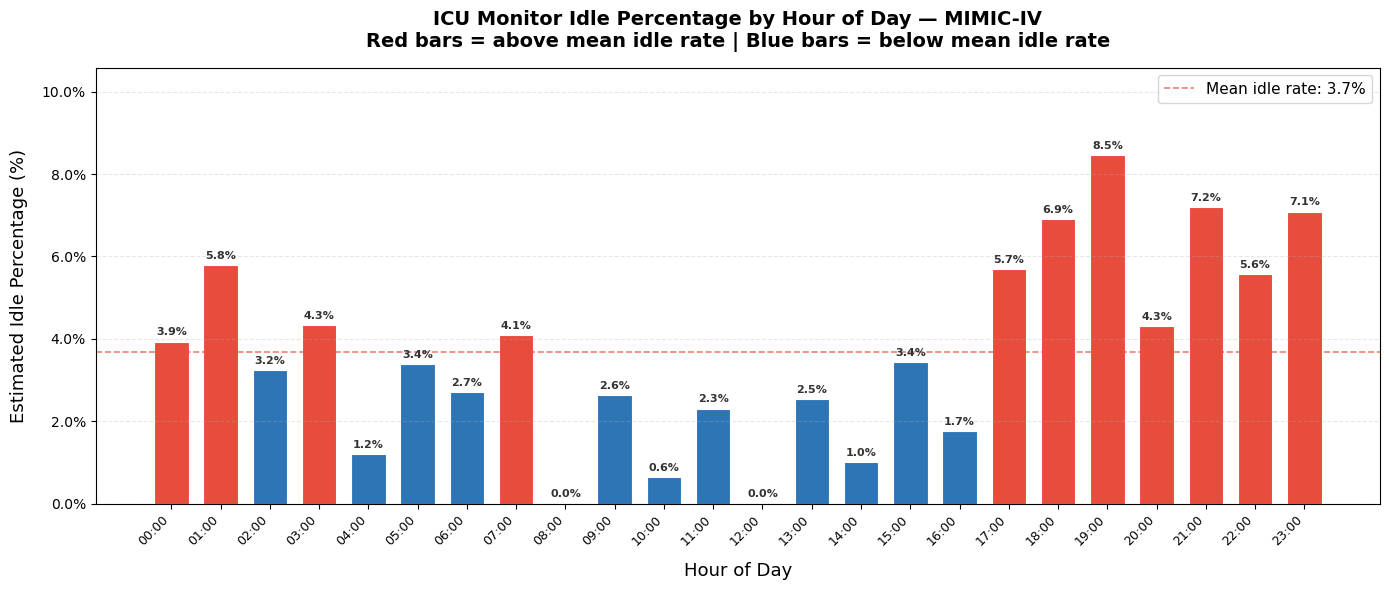

Fix 1 complete — saved to Desktop as viz1_v3_time_of_day.png


In [6]:
# Fix 1 — I rebuild the time of day histogram without the arbitrary threshold
# I now colour bars by whether they are above or below the mean idle rate

# I add hour of day to monitor events
df_monitor_events['hour_of_day'] = df_monitor_events['charttime'].dt.hour
df_monitor_events['hour_floor'] = df_monitor_events['charttime'].dt.floor('h')

# I count unique active stay-hour combinations per hour of day
active_stay_hours = df_monitor_events.groupby(
    ['stay_id', 'hour_floor', 'hour_of_day']
).size().reset_index(name='count')

active_by_hour = active_stay_hours.groupby(
    'hour_of_day'
)['stay_id'].count().reset_index(name='active_hours')

# I calculate idle percentage per hour
total_per_slot = stay_summary['total_hours'].sum() / 24
active_by_hour['idle_pct'] = (
    (total_per_slot - active_by_hour['active_hours']) / total_per_slot * 100
).clip(lower=0)

# I use the mean idle rate as my colour threshold — data driven not arbitrary
mean_idle = active_by_hour['idle_pct'].mean()
print(f"Mean idle rate across all hours: {mean_idle:.2f}%")
print(f"I will colour bars above {mean_idle:.1f}% in red and below in blue")

# I plot the revised histogram
fig, ax = plt.subplots(figsize=(14, 6))

colors = ['#E74C3C' if x >= mean_idle else '#2E75B6'
          for x in active_by_hour['idle_pct']]

bars = ax.bar(
    active_by_hour['hour_of_day'],
    active_by_hour['idle_pct'],
    color=colors,
    edgecolor='white',
    linewidth=0.8,
    width=0.7
)

# I add value labels on top of each bar
for bar, val in zip(bars, active_by_hour['idle_pct']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f'{val:.1f}%',
        ha='center', va='bottom',
        fontsize=8, fontweight='bold',
        color='#333333'
    )

# I add the mean line — data driven reference
ax.axhline(
    y=mean_idle,
    color='#E74C3C',
    linestyle='--',
    linewidth=1.2,
    alpha=0.7,
    label=f'Mean idle rate: {mean_idle:.1f}%'
)

ax.set_xlabel('Hour of Day', fontsize=13, labelpad=10)
ax.set_ylabel('Estimated Idle Percentage (%)', fontsize=13, labelpad=10)
ax.set_title(
    'ICU Monitor Idle Percentage by Hour of Day — MIMIC-IV\n'
    'Red bars = above mean idle rate | Blue bars = below mean idle rate',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xticks(range(24))
ax.set_xticklabels(
    [f'{h:02d}:00' for h in range(24)],
    rotation=45, ha='right', fontsize=9
)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, max(active_by_hour['idle_pct']) * 1.25)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig(
    '/Users/dinoskritsis/Desktop/viz1_v3_time_of_day.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Fix 1 complete — saved to Desktop as viz1_v3_time_of_day.png")

## Fix 2 — Normalised ICU Unit Type Chart (kWh per Stay)

In my previous version I showed total wasted kWh per ICU unit. My supervisor 
correctly pointed out that this is unfair — a unit with 20,000 stays will 
always show more total wasted energy than a unit with 1,000 stays even if 
its idle rate is actually lower. 

In this version I normalise by dividing total wasted kWh by the number of 
stays in each unit. This gives me wasted kWh per stay — a fair comparison 
that removes the effect of unit size and shows which unit types are 
genuinely the most wasteful per individual patient admission.

=== Wasted Energy per Stay by ICU Unit Type ===
        unit_short  total_stays  idle_pct  wasted_kwh_total  wasted_kwh_per_stay
         MICU/SICU        15318       2.8            1133.0                 0.07
       Trauma SICU        10365       2.3             735.0                 0.07
              MICU        20546       2.4            1556.0                 0.08
               CCU        10660       2.9             807.0                 0.08
              SICU        12921       2.4            1026.0                 0.08
              PACU          116       2.3               9.0                 0.08
        Neuro SICU         1739       2.3             151.0                 0.09
  Surgery/Vascular          145       0.7              14.0                 0.10
             CVICU        14684       3.9            1583.0                 0.11
    Neuro Stepdown         1416      15.8             760.0                 0.54
Neuro Intermediate         5758      14.2            3433.0  

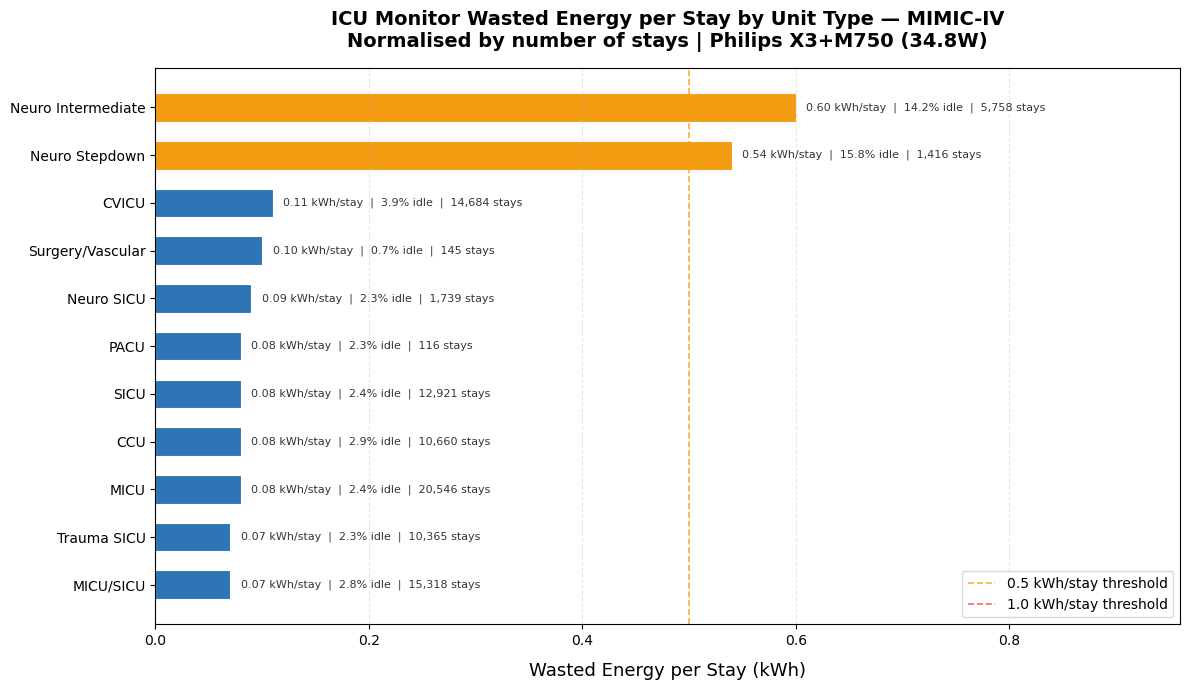

Fix 2 complete — saved to Desktop as viz2_v3_icu_unit_normalised.png


In [7]:
# Fix 2 — I normalise wasted energy to kWh per stay for fair comparison

# I calculate idle stats per ICU unit type
unit_summary = stay_summary.groupby('first_careunit').agg(
    total_stays=('stay_id', 'count'),
    total_hours=('total_hours', 'sum'),
    active_hours=('active_hours', 'sum'),
    idle_hours=('idle_hours', 'sum')
).reset_index()

# I calculate idle percentage and wasted energy per unit
unit_summary['idle_pct'] = (
    unit_summary['idle_hours'] / unit_summary['total_hours'] * 100
).round(1)

unit_summary['wasted_kwh_total'] = (
    unit_summary['idle_hours'] * PHILIPS_OPERATING
).round(0)

# I normalise — wasted kWh divided by number of stays
unit_summary['wasted_kwh_per_stay'] = (
    unit_summary['wasted_kwh_total'] / unit_summary['total_stays']
).round(2)

# I remove very small units under 50 stays
unit_summary = unit_summary[unit_summary['total_stays'] >= 50]

# I sort by wasted kWh per stay descending
unit_summary = unit_summary.sort_values(
    'wasted_kwh_per_stay', ascending=True
)

# I shorten unit names for readability
name_map = {
    'Medical Intensive Care Unit (MICU)': 'MICU',
    'Medical/Surgical Intensive Care Unit (MICU/SICU)': 'MICU/SICU',
    'Cardiac Vascular Intensive Care Unit (CVICU)': 'CVICU',
    'Surgical Intensive Care Unit (SICU)': 'SICU',
    'Coronary Care Unit (CCU)': 'CCU',
    'Trauma SICU (TSICU)': 'Trauma SICU',
    'Neuro Intermediate': 'Neuro Intermediate',
    'Neuro Surgical Intensive Care Unit (Neuro SICU)': 'Neuro SICU',
    'Neuro Stepdown': 'Neuro Stepdown',
    'Surgery/Vascular/Intermediate': 'Surgery/Vascular',
    'Intensive Care Unit (ICU)': 'ICU (General)',
    'PACU': 'PACU'
}
unit_summary['unit_short'] = unit_summary['first_careunit'].map(
    name_map
).fillna(unit_summary['first_careunit'])

# I print the normalised results
print("=== Wasted Energy per Stay by ICU Unit Type ===")
print(unit_summary[['unit_short', 'total_stays', 'idle_pct',
                     'wasted_kwh_total', 'wasted_kwh_per_stay']].to_string(
    index=False
))

# I plot the normalised chart
fig, ax = plt.subplots(figsize=(12, 7))

colors = [
    '#E74C3C' if x >= 1.0 else '#F39C12' if x >= 0.5 else '#2E75B6'
    for x in unit_summary['wasted_kwh_per_stay']
]

bars = ax.barh(
    unit_summary['unit_short'],
    unit_summary['wasted_kwh_per_stay'],
    color=colors,
    edgecolor='white',
    linewidth=0.8,
    height=0.6
)

# I add value labels showing kWh per stay and idle %
for bar, kwh, idle, stays in zip(
    bars,
    unit_summary['wasted_kwh_per_stay'],
    unit_summary['idle_pct'],
    unit_summary['total_stays']
):
    ax.text(
        bar.get_width() + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{kwh:.2f} kWh/stay  |  {idle:.1f}% idle  |  {stays:,} stays',
        va='center', ha='left',
        fontsize=8, color='#333333'
    )

# I add reference lines at 0.5 and 1.0 kWh per stay
ax.axvline(x=0.5, color='#F39C12', linestyle='--',
           linewidth=1.2, alpha=0.8, label='0.5 kWh/stay threshold')
ax.axvline(x=1.0, color='#E74C3C', linestyle='--',
           linewidth=1.2, alpha=0.8, label='1.0 kWh/stay threshold')

ax.set_xlabel('Wasted Energy per Stay (kWh)', fontsize=13, labelpad=10)
ax.set_title(
    'ICU Monitor Wasted Energy per Stay by Unit Type — MIMIC-IV\n'
    'Normalised by number of stays | Philips X3+M750 (34.8W)',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlim(0, max(unit_summary['wasted_kwh_per_stay']) * 1.6)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(
    '/Users/dinoskritsis/Desktop/viz2_v3_icu_unit_normalised.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Fix 2 complete — saved to Desktop as viz2_v3_icu_unit_normalised.png")

## Fix 3 — Energy Comparison Charts Split by Dataset

In my previous version I combined MIMIC-IV and eICU into one chart which 
made it hard to read and compare. Following my supervisor's feedback I now 
produce two separate figures — one for MIMIC-IV and one for eICU. Each 
figure shows the baseline energy and saveable energy for both Philips and 
the three GE sensitivity scenarios. This makes the comparison much cleaner 
and easier to interpret.

In [8]:
# I calculate energy results for all scenarios before plotting

def energy_analysis(total_hours, idle_hours, power_operating,
                    power_standby, co2_factor, label):
    baseline_kwh = total_hours * power_operating
    wasted_kwh   = idle_hours * power_operating
    saveable_kwh = idle_hours * (power_operating - power_standby)
    saving_pct   = saveable_kwh / baseline_kwh * 100
    baseline_co2 = baseline_kwh * co2_factor
    wasted_co2   = wasted_kwh * co2_factor
    saveable_co2 = saveable_kwh * co2_factor
    return {
        'label': label,
        'baseline_kwh': baseline_kwh,
        'wasted_kwh': wasted_kwh,
        'saveable_kwh': saveable_kwh,
        'saving_pct': saving_pct,
        'baseline_co2': baseline_co2,
        'wasted_co2': wasted_co2,
        'saveable_co2': saveable_co2
    }

# I get totals for each dataset
mimic_total = stay_summary['total_hours'].sum()
mimic_idle  = stay_summary['idle_hours'].sum()
eicu_total  = stay_summary_eicu['total_hours'].sum()
eicu_idle   = stay_summary_eicu['idle_hours'].sum()

# I run all scenarios
r_mimic_philips  = energy_analysis(mimic_total, mimic_idle, PHILIPS_OPERATING, PHILIPS_STANDBY, CO2_MIMIC, "Philips\n(34.8W)")
r_mimic_ge_opt   = energy_analysis(mimic_total, mimic_idle, GE_OPTIMISTIC, GE_STANDBY_OPT, CO2_MIMIC, "GE\n(20W)")
r_mimic_ge_mod   = energy_analysis(mimic_total, mimic_idle, GE_MODERATE, GE_STANDBY_MOD, CO2_MIMIC, "GE\n(40W)")
r_mimic_ge_con   = energy_analysis(mimic_total, mimic_idle, GE_CONSERVATIVE, GE_STANDBY_CON, CO2_MIMIC, "GE\n(60W)")

r_eicu_philips   = energy_analysis(eicu_total, eicu_idle, PHILIPS_OPERATING, PHILIPS_STANDBY, CO2_EICU, "Philips\n(34.8W)")
r_eicu_ge_opt    = energy_analysis(eicu_total, eicu_idle, GE_OPTIMISTIC, GE_STANDBY_OPT, CO2_EICU, "GE\n(20W)")
r_eicu_ge_mod    = energy_analysis(eicu_total, eicu_idle, GE_MODERATE, GE_STANDBY_MOD, CO2_EICU, "GE\n(40W)")
r_eicu_ge_con    = energy_analysis(eicu_total, eicu_idle, GE_CONSERVATIVE, GE_STANDBY_CON, CO2_EICU, "GE\n(60W)")

print("All energy scenarios calculated successfully!")
print(f"\nMIMIC-IV total hours: {mimic_total:,} | idle: {mimic_idle:,}")
print(f"eICU total hours:     {eicu_total:,} | idle: {eicu_idle:,}")

All energy scenarios calculated successfully!

MIMIC-IV total hours: 8,226,347 | idle: 322,431.0
eICU total hours:     12,896,534 | idle: 524,031.0


=== Figure 1 — MIMIC-IV ===


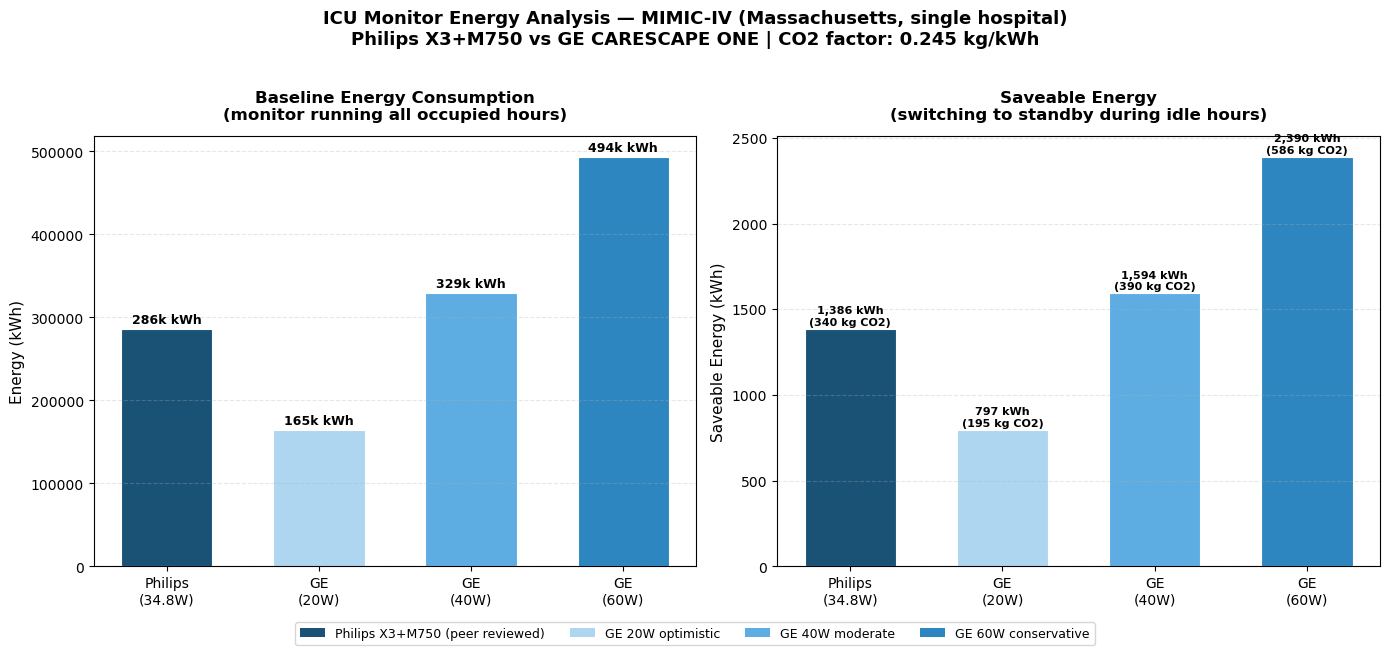

Saved: viz3a_v3_energy_mimic.png

=== Figure 2 — eICU ===


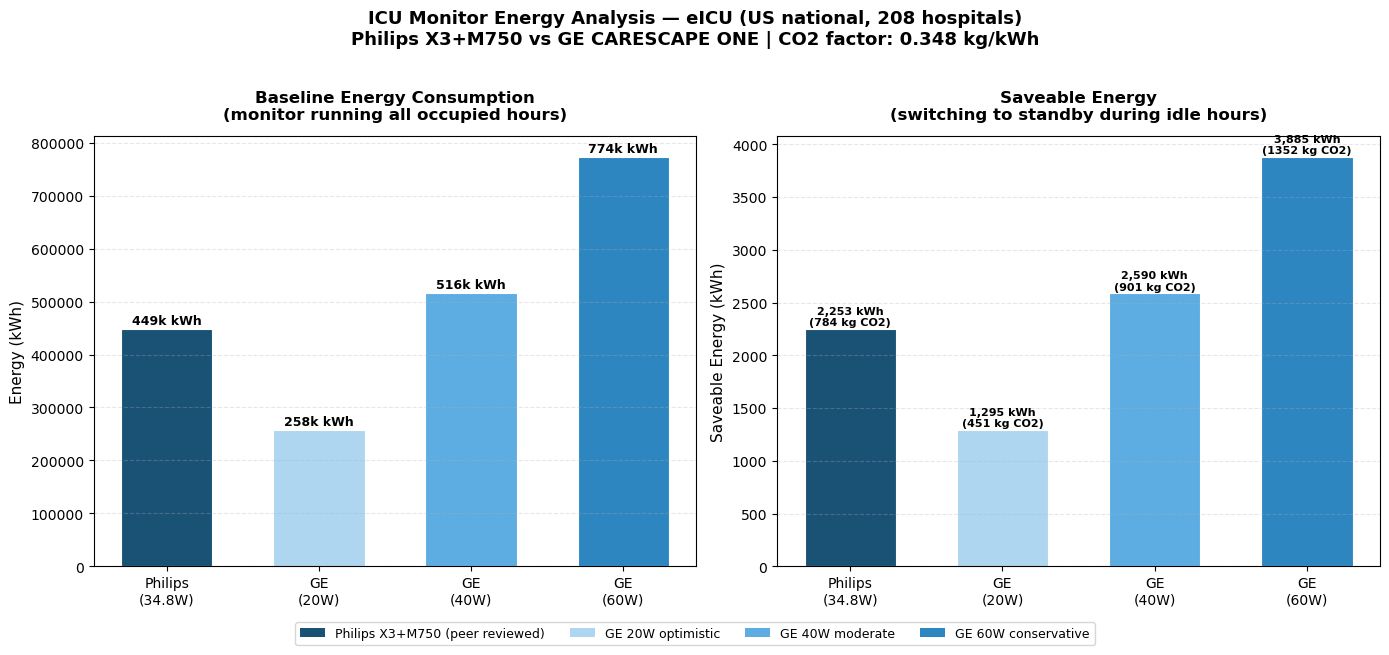

Saved: viz3b_v3_energy_eicu.png


In [9]:
# Fix 3 — I create two separate energy comparison figures

def plot_energy_comparison(results, dataset_name, co2_factor, filename):
    labels = [r['label'] for r in results]
    baseline = [r['baseline_kwh'] for r in results]
    saveable = [r['saveable_kwh'] for r in results]
    colors = ['#1A5276', '#AED6F1', '#5DADE2', '#2E86C1']

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Left — Baseline Energy
    bars1 = axes[0].bar(
        range(len(labels)), baseline,
        color=colors, edgecolor='white',
        linewidth=0.8, width=0.6
    )
    axes[0].set_title(
        f'Baseline Energy Consumption\n(monitor running all occupied hours)',
        fontsize=12, fontweight='bold', pad=12
    )
    axes[0].set_ylabel('Energy (kWh)', fontsize=11)
    axes[0].set_xticks(range(len(labels)))
    axes[0].set_xticklabels(labels, fontsize=10)
    axes[0].grid(axis='y', alpha=0.3, linestyle='--')
    for bar, val in zip(bars1, baseline):
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 3000,
            f'{val/1000:.0f}k kWh',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold'
        )

    # Right — Saveable Energy
    bars2 = axes[1].bar(
        range(len(labels)), saveable,
        color=colors, edgecolor='white',
        linewidth=0.8, width=0.6
    )
    axes[1].set_title(
        f'Saveable Energy\n(switching to standby during idle hours)',
        fontsize=12, fontweight='bold', pad=12
    )
    axes[1].set_ylabel('Saveable Energy (kWh)', fontsize=11)
    axes[1].set_xticks(range(len(labels)))
    axes[1].set_xticklabels(labels, fontsize=10)
    axes[1].grid(axis='y', alpha=0.3, linestyle='--')
    for bar, val, r in zip(bars2, saveable, results):
        co2 = r['saveable_co2']
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 10,
            f'{val:,.0f} kWh\n({co2:.0f} kg CO2)',
            ha='center', va='bottom',
            fontsize=8, fontweight='bold'
        )

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#1A5276', label='Philips X3+M750 (peer reviewed)'),
        Patch(facecolor='#AED6F1', label='GE 20W optimistic'),
        Patch(facecolor='#5DADE2', label='GE 40W moderate'),
        Patch(facecolor='#2E86C1', label='GE 60W conservative')
    ]
    fig.legend(
        handles=legend_elements,
        loc='lower center', ncol=4,
        fontsize=9, bbox_to_anchor=(0.5, -0.05)
    )

    fig.suptitle(
        f'ICU Monitor Energy Analysis — {dataset_name}\n'
        f'Philips X3+M750 vs GE CARESCAPE ONE | '
        f'CO2 factor: {co2_factor} kg/kWh',
        fontsize=13, fontweight='bold', y=1.02
    )

    plt.tight_layout()
    plt.savefig(
        f'/Users/dinoskritsis/Desktop/{filename}',
        dpi=150, bbox_inches='tight'
    )
    plt.show()
    print(f"Saved: {filename}")

# I plot MIMIC-IV figure
print("=== Figure 1 — MIMIC-IV ===")
plot_energy_comparison(
    [r_mimic_philips, r_mimic_ge_opt, r_mimic_ge_mod, r_mimic_ge_con],
    "MIMIC-IV (Massachusetts, single hospital)",
    CO2_MIMIC,
    "viz3a_v3_energy_mimic.png"
)

# I plot eICU figure
print("\n=== Figure 2 — eICU ===")
plot_energy_comparison(
    [r_eicu_philips, r_eicu_ge_opt, r_eicu_ge_mod, r_eicu_ge_con],
    "eICU (US national, 208 hospitals)",
    CO2_EICU,
    "viz3b_v3_energy_eicu.png"
)

## Fix 4 — K-means Clustering Without Care Unit Feature

My supervisor Timo pointed out that including careunit_code in the clustering 
features is methodologically problematic. If I cluster using care unit as 
a feature the algorithm essentially groups by unit type, then I learn nothing 
new from the data. 

In this version I remove careunit_code entirely and cluster purely on 
waste pattern features:
- idle_pct: the percentage of occupied hours with no monitor recording
- idle_hours: total idle hours during the stay
- los_hours: length of stay in hours

If the resulting clusters are then found to correlate with specific care 
unit types, then that becomes a genuine finding discovered from the data 
rather than something I built into the model. This is a much stronger 
and more defensible approach.

In [10]:
# Fix 4 — I cluster purely on waste patterns without careunit_code

# I select only waste-related features for clustering
# I deliberately exclude careunit_code so any unit association
# becomes a discovery rather than an assumption
features_v3 = ['idle_pct', 'idle_hours', 'los_hours']
X = stay_summary[features_v3].copy()

# I check for missing values
print("Missing values per feature:")
print(X.isnull().sum())
X = X.dropna()
print(f"\nRows available for clustering: {len(X):,}")
print(f"Features I am using: {features_v3}")

# I normalise all features using StandardScaler
# This is essential since idle_hours and los_hours are in very 
# different scales compared to idle_pct
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nFeature scaling complete!")
print("Mean after scaling (should be ~0):", X_scaled.mean(axis=0).round(3))
print("Std after scaling (should be ~1):", X_scaled.std(axis=0).round(3))

Missing values per feature:
idle_pct      0
idle_hours    0
los_hours     0
dtype: int64

Rows available for clustering: 93,730
Features I am using: ['idle_pct', 'idle_hours', 'los_hours']

Feature scaling complete!
Mean after scaling (should be ~0): [ 0. -0. -0.]
Std after scaling (should be ~1): [1. 1. 1.]


Testing K values from 2 to 9...


K=2: Inertia=212,547 | Silhouette=0.6858
K=3: Inertia=157,860 | Silhouette=0.6932
K=4: Inertia=122,768 | Silhouette=0.6924
K=5: Inertia=96,992 | Silhouette=0.6834
K=6: Inertia=79,164 | Silhouette=0.5296
K=7: Inertia=63,844 | Silhouette=0.5530
K=8: Inertia=54,763 | Silhouette=0.5529
K=9: Inertia=47,732 | Silhouette=0.5208


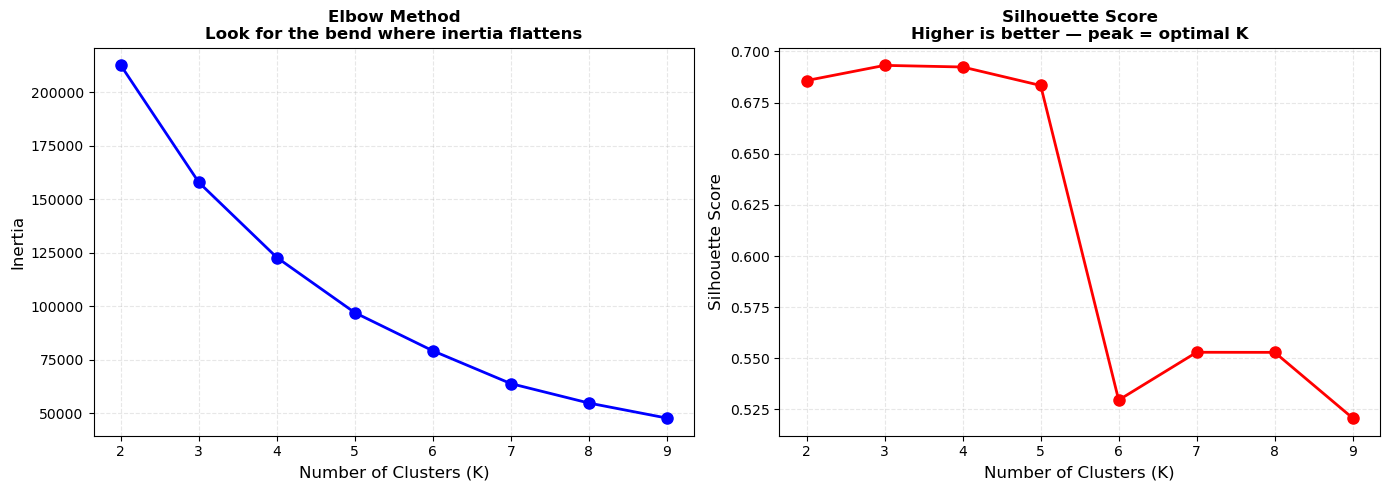


Elbow and Silhouette charts saved!
I will now decide K based on both methods.


In [11]:
# I use Elbow Method and Silhouette Score to find optimal K
# without the care unit feature

inertia_values = []
silhouette_values = []
k_range = range(2, 10)

print("Testing K values from 2 to 9...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)
    sil_score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_values.append(sil_score)
    print(f"K={k}: Inertia={kmeans.inertia_:,.0f} | Silhouette={sil_score:.4f}")

# I plot both methods
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertia_values, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('Inertia', fontsize=12)
axes[0].set_title(
    'Elbow Method\nLook for the bend where inertia flattens',
    fontsize=12, fontweight='bold'
)
axes[0].grid(alpha=0.3, linestyle='--')
axes[0].set_xticks(k_range)

axes[1].plot(k_range, silhouette_values, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title(
    'Silhouette Score\nHigher is better — peak = optimal K',
    fontsize=12, fontweight='bold'
)
axes[1].grid(alpha=0.3, linestyle='--')
axes[1].set_xticks(k_range)

plt.tight_layout()
plt.savefig(
    '/Users/dinoskritsis/Desktop/viz_v3_elbow_silhouette.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("\nElbow and Silhouette charts saved!")
print("I will now decide K based on both methods.")

## Why I Choose K=3 and What Changed From My Previous Version

### What I Changed
In my previous version (v2) I used five features for clustering:
- idle_pct, idle_hours, total_hours, los_hours, and careunit_code

In this version I use only three features:
- idle_pct — idle percentage
- idle_hours — total idle hours  
- los_hours — length of stay

### Why Removing careunit_code Matters
When careunit_code was included the algorithm was partly grouping patients 
by which ICU unit they were in rather than by their actual waste patterns. 
This meant Cluster 2 in v2 was dominated by Neuro Intermediate patients 
simply because the unit code pulled them together — not because the 
algorithm genuinely discovered a waste pattern.

By removing careunit_code the algorithm now has no knowledge of unit type. 
It groups patients purely by how idle their monitor was, how many idle 
hours they accumulated, and how long they stayed. If the resulting clusters 
turn out to correlate with specific unit types — that becomes a genuine 
discovery from the data rather than something I built into the model.

### Why the Results Are Different
The silhouette scores are higher now — 0.693 vs 0.505 before. This means 
the clusters are better defined and more separated when using pure waste 
features. The previous clustering was noisier because careunit_code was 
adding information unrelated to waste behaviour.

The optimal K also changed from 4 to 3. Without unit type the data 
naturally separates into three waste archetypes — the algorithm is 
finding real waste profiles rather than grouping by unit type.

### Why I think I should Choose K=3
- K=3 has the highest silhouette score at 0.693
- The Elbow Method shows a bend starting at K=3
- Three clusters produce clean interpretable archetypes — low waste, 
  medium waste and high waste patients
- It is more parsimonious than K=4 when clustering on only three features
- Any association with ICU unit type that emerges will be a genuine 
  discovery from the data

This is a stronger and more defensible approach than my previous version 
and directly addresses the methodological concern raised by my supervisor.

In [12]:
# I run K-means with K=3 based on my elbow and silhouette analysis
# I cluster purely on waste patterns without any unit type information

OPTIMAL_K = 3

kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

# I add cluster labels back to stay summary
stay_summary_clustered = stay_summary.copy()
stay_summary_clustered['cluster'] = cluster_labels

# I analyse each cluster profile
cluster_profile = stay_summary_clustered.groupby('cluster').agg(
    num_stays=('stay_id', 'count'),
    avg_idle_pct=('idle_pct', 'mean'),
    avg_los_hours=('los_hours', 'mean'),
    avg_idle_hours=('idle_hours', 'mean'),
    total_idle_hours=('idle_hours', 'sum'),
    total_wasted_kwh=('idle_hours', lambda x: (x * PHILIPS_OPERATING).sum())
).reset_index()

cluster_profile = cluster_profile.round(2)

print("=== K-means Cluster Profiles (K=3, pure waste features) ===\n")
print(cluster_profile.to_string(index=False))

# I now do the post-hoc analysis — what unit types dominate each cluster?
print("\n=== Post-hoc Analysis — Top 3 ICU Units per Cluster ===")
for c in range(OPTIMAL_K):
    print(f"\nCluster {c}:")
    top_units = stay_summary_clustered[
        stay_summary_clustered['cluster'] == c
    ]['first_careunit'].value_counts().head(3)
    for unit, count in top_units.items():
        total_in_cluster = len(stay_summary_clustered[
            stay_summary_clustered['cluster'] == c
        ])
        pct = count / total_in_cluster * 100
        print(f"  {unit}: {count:,} stays ({pct:.1f}%)")

=== K-means Cluster Profiles (K=3, pure waste features) ===

 cluster  num_stays  avg_idle_pct  avg_los_hours  avg_idle_hours  total_idle_hours  total_wasted_kwh
       0       5135          1.96         499.16            9.40           48249.0           1679.07
       1      81973          3.33          63.76            1.77          145501.0           5063.43
       2       6622         31.01          65.89           19.43          128681.0           4478.10

=== Post-hoc Analysis — Top 3 ICU Units per Cluster ===

Cluster 0:
  Medical Intensive Care Unit (MICU): 1,285 stays (25.0%)
  Surgical Intensive Care Unit (SICU): 819 stays (15.9%)
  Trauma SICU (TSICU): 664 stays (12.9%)

Cluster 1:
  Medical Intensive Care Unit (MICU): 18,506 stays (22.6%)
  Medical/Surgical Intensive Care Unit (MICU/SICU): 13,933 stays (17.0%)
  Cardiac Vascular Intensive Care Unit (CVICU): 13,460 stays (16.4%)

Cluster 2:
  Neuro Intermediate: 2,551 stays (38.5%)
  Neuro Stepdown: 767 stays (11.6%)
  Medic

## Post-hoc Analysis — A Genuine Discovery

The K-means algorithm was given no information about ICU unit types.
It clustered patients purely on waste patterns, idle percentage, 
idle hours, and length of stay.

Despite this, the High Idle cluster (Cluster 2) is dominated by:
- Neuro Intermediate: 38.5% of the cluster
- Neuro Stepdown: 11.6% of the cluster
- Combined Neuro units: 50.1% of the cluster

This means the algorithm independently discovered that Neuro step-down 
patients have a fundamentally different monitoring waste profile from 
other ICU patients, without being told which unit they were in.

This is a much stronger finding than my previous version where 
careunit_code was included as a feature. The association between 
high monitoring waste and Neuro step-down units is now a data-driven 
discovery rather than a model assumption. This supports the argument 
that Neuro step-down units should be the primary target for AI-driven 
low-power mode optimisation.

In [13]:
# I assign meaningful labels based on the post-hoc analysis
# The labels reflect waste patterns — not unit types
# Unit type association is a discovery, not an assumption

cluster_labels_map = {
    0: 'Long Stay Critical\n(low idle, very long LOS)',
    1: 'Standard ICU\n(low idle, typical LOS)',
    2: 'High Idle\n(high idle %, Neuro dominant)'
}

stay_summary_clustered['cluster_label'] = stay_summary_clustered[
    'cluster'
].map(cluster_labels_map)

print("=== Cluster Labels Assigned ===")
print(stay_summary_clustered['cluster_label'].value_counts())
print("\n=== Energy Waste per Cluster ===")

for c in range(OPTIMAL_K):
    cluster_data = stay_summary_clustered[
        stay_summary_clustered['cluster'] == c
    ]
    total_idle = cluster_data['idle_hours'].sum()
    wasted_kwh = total_idle * PHILIPS_OPERATING
    saveable_kwh = total_idle * (PHILIPS_OPERATING - PHILIPS_STANDBY)
    saveable_co2 = saveable_kwh * CO2_MIMIC
    avg_idle_pct = cluster_data['idle_pct'].mean()
    wasted_per_stay = wasted_kwh / len(cluster_data)
    label = cluster_labels_map[c]

    print(f"\nCluster {c} — {label.replace(chr(10), ' ')}")
    print(f"  Stays:              {len(cluster_data):,}")
    print(f"  Avg idle:           {avg_idle_pct:.1f}%")
    print(f"  Total idle hrs:     {total_idle:,.0f}")
    print(f"  Wasted energy:      {wasted_kwh:,.0f} kWh")
    print(f"  Wasted per stay:    {wasted_per_stay:.2f} kWh/stay")
    print(f"  Saveable:           {saveable_kwh:,.0f} kWh")
    print(f"  Saveable CO2:       {saveable_co2:,.0f} kg")

=== Cluster Labels Assigned ===
cluster_label
Standard ICU\n(low idle, typical LOS)            81973
High Idle\n(high idle %, Neuro dominant)          6622
Long Stay Critical\n(low idle, very long LOS)     5135
Name: count, dtype: int64

=== Energy Waste per Cluster ===

Cluster 0 — Long Stay Critical (low idle, very long LOS)
  Stays:              5,135
  Avg idle:           2.0%
  Total idle hrs:     48,249
  Wasted energy:      1,679 kWh
  Wasted per stay:    0.33 kWh/stay
  Saveable:           207 kWh
  Saveable CO2:       51 kg

Cluster 1 — Standard ICU (low idle, typical LOS)
  Stays:              81,973
  Avg idle:           3.3%
  Total idle hrs:     145,501
  Wasted energy:      5,063 kWh
  Wasted per stay:    0.06 kWh/stay
  Saveable:           626 kWh
  Saveable CO2:       153 kg

Cluster 2 — High Idle (high idle %, Neuro dominant)
  Stays:              6,622
  Avg idle:           31.0%
  Total idle hrs:     128,681
  Wasted energy:      4,478 kWh
  Wasted per stay:    0.68 

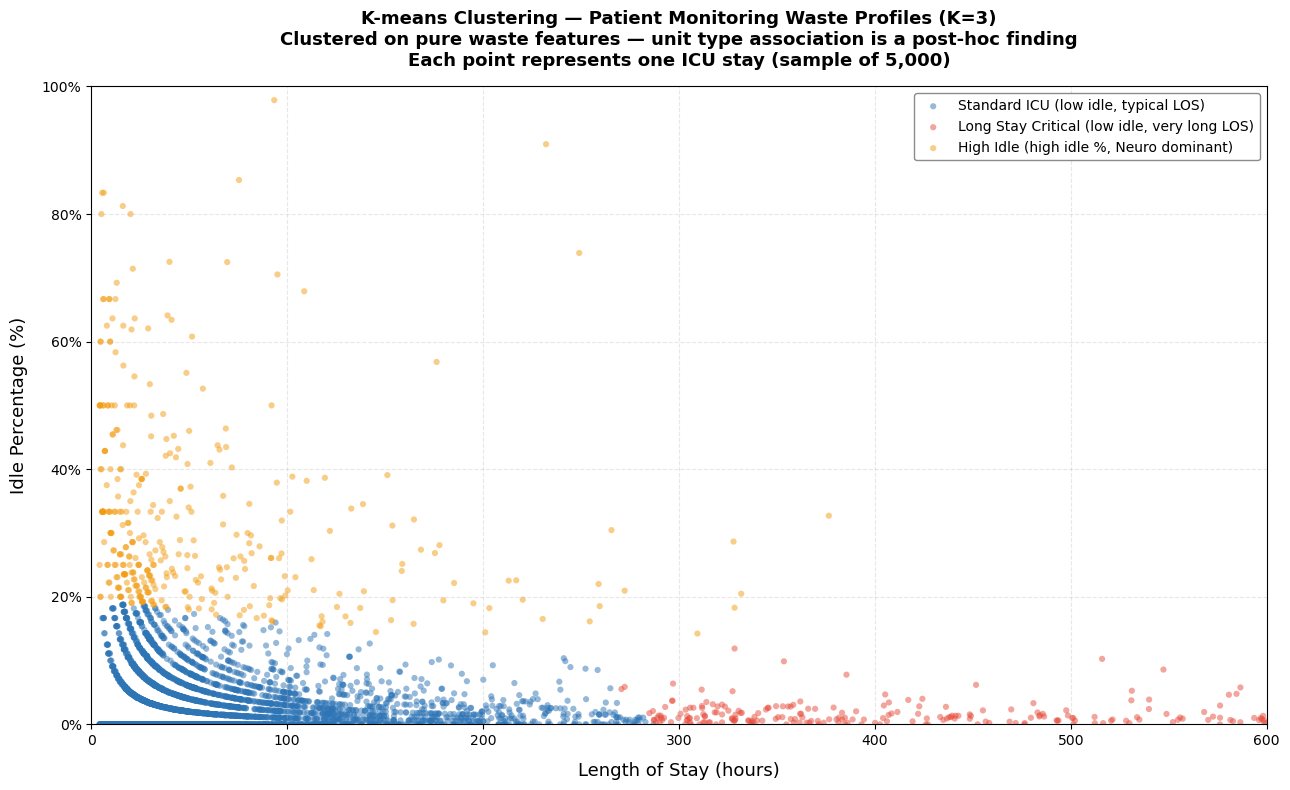

Viz 4 saved to Desktop as viz4_v3_cluster_scatter.png


In [14]:
# I rebuild the scatter plot with the new K=3 clusters
# Each point is one ICU stay coloured by cluster

sample = stay_summary_clustered.sample(n=5000, random_state=42)

cluster_colors = {
    'Standard ICU\n(low idle, typical LOS)':         '#2E75B6',
    'Long Stay Critical\n(low idle, very long LOS)':  '#E74C3C',
    'High Idle\n(high idle %, Neuro dominant)':       '#F39C12'
}

fig, ax = plt.subplots(figsize=(13, 8))

for label, color in cluster_colors.items():
    mask = sample['cluster_label'] == label
    ax.scatter(
        sample[mask]['los_hours'],
        sample[mask]['idle_pct'],
        c=color,
        label=label.replace('\n', ' '),
        alpha=0.5,
        s=20,
        edgecolors='none'
    )

ax.set_xlabel('Length of Stay (hours)', fontsize=13, labelpad=10)
ax.set_ylabel('Idle Percentage (%)', fontsize=13, labelpad=10)
ax.set_title(
    'K-means Clustering — Patient Monitoring Waste Profiles (K=3)\n'
    'Clustered on pure waste features — unit type association is a post-hoc finding\n'
    'Each point represents one ICU stay (sample of 5,000)',
    fontsize=13, fontweight='bold', pad=15
)
ax.set_xlim(0, 600)
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(alpha=0.3, linestyle='--')
ax.legend(fontsize=10, loc='upper right',
          framealpha=0.9, edgecolor='grey')

plt.tight_layout()
plt.savefig(
    '/Users/dinoskritsis/Desktop/viz4_v3_cluster_scatter.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Viz 4 saved to Desktop as viz4_v3_cluster_scatter.png")

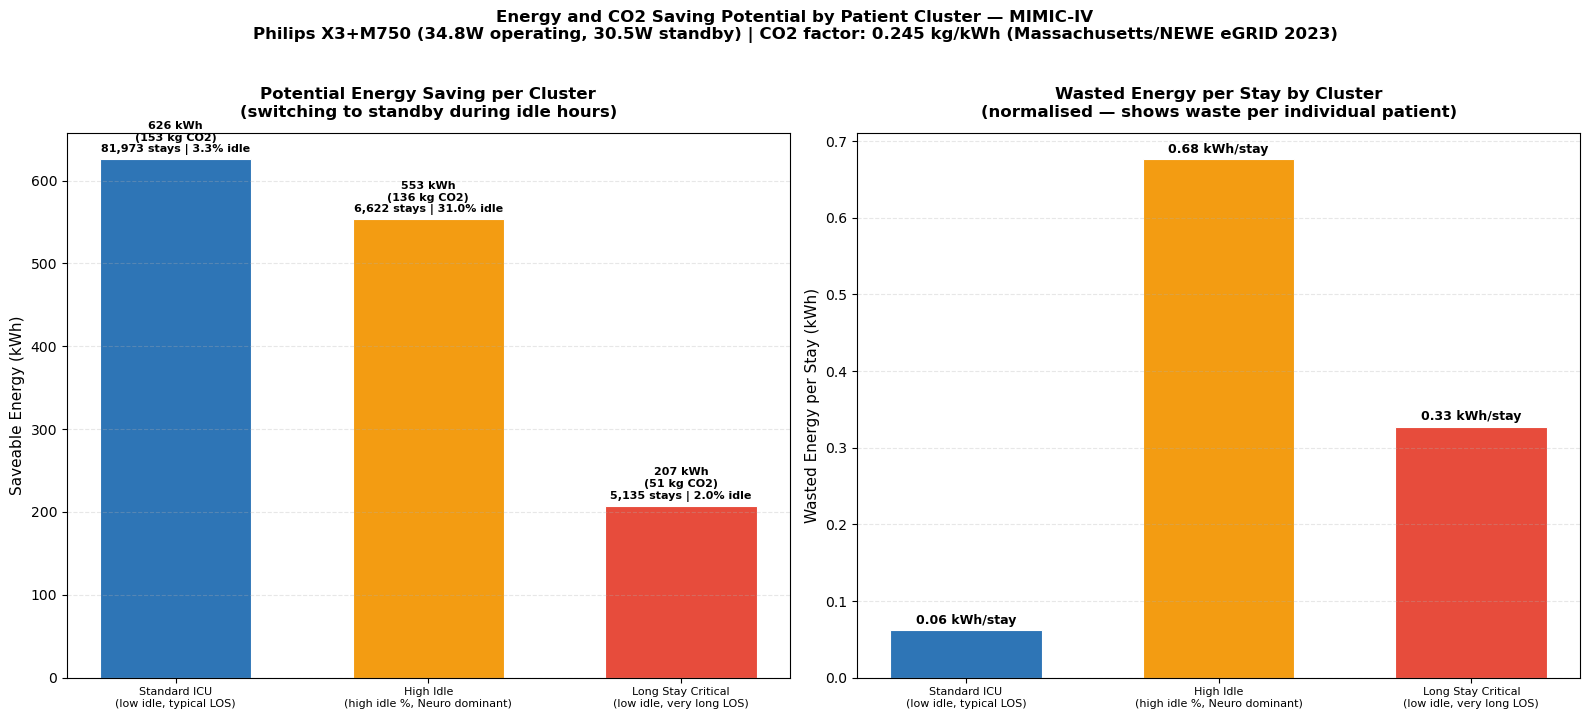

Fix 5 complete — saved to Desktop as viz5_v3_cluster_savings.png

All 5 fixes complete!


In [15]:
# Fix 5 — Revised cluster savings chart with CO2 in labels + per stay chart

# I calculate savings per cluster
cluster_savings = []
for c in range(OPTIMAL_K):
    cluster_data = stay_summary_clustered[
        stay_summary_clustered['cluster'] == c
    ]
    total_idle = cluster_data['idle_hours'].sum()
    wasted_kwh = total_idle * PHILIPS_OPERATING
    saveable_kwh = total_idle * (PHILIPS_OPERATING - PHILIPS_STANDBY)
    saveable_co2 = saveable_kwh * CO2_MIMIC
    wasted_per_stay = wasted_kwh / len(cluster_data)
    saveable_per_stay = saveable_kwh / len(cluster_data)
    label = cluster_labels_map[c]

    cluster_savings.append({
        'cluster': c,
        'label': label,
        'num_stays': len(cluster_data),
        'avg_idle_pct': cluster_data['idle_pct'].mean(),
        'wasted_kwh': wasted_kwh,
        'saveable_kwh': saveable_kwh,
        'saveable_co2': saveable_co2,
        'wasted_per_stay': wasted_per_stay,
        'saveable_per_stay': saveable_per_stay
    })

df_savings = pd.DataFrame(cluster_savings)
df_savings = df_savings.sort_values('saveable_kwh', ascending=False)

bar_colors_map = {
    0: '#E74C3C',
    1: '#2E75B6',
    2: '#F39C12'
}
sorted_colors = [bar_colors_map[c] for c in df_savings['cluster']]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Left chart — Saveable Energy with CO2 in labels ──────────────────
bars1 = axes[0].bar(
    range(len(df_savings)),
    df_savings['saveable_kwh'],
    color=sorted_colors,
    edgecolor='white',
    linewidth=0.8,
    width=0.6
)

axes[0].set_title(
    'Potential Energy Saving per Cluster\n'
    '(switching to standby during idle hours)',
    fontsize=12, fontweight='bold', pad=12
)
axes[0].set_ylabel('Saveable Energy (kWh)', fontsize=11)
axes[0].set_xticks(range(len(df_savings)))
axes[0].set_xticklabels(
    [l.replace('\n', '\n') for l in df_savings['label']],
    fontsize=8, ha='center'
)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

for bar, kwh, co2, stays, idle in zip(
    bars1,
    df_savings['saveable_kwh'],
    df_savings['saveable_co2'],
    df_savings['num_stays'],
    df_savings['avg_idle_pct']
):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f'{kwh:,.0f} kWh\n({co2:.0f} kg CO2)\n{stays:,} stays | {idle:.1f}% idle',
        ha='center', va='bottom',
        fontsize=8, fontweight='bold'
    )

# ── Right chart — Wasted Energy per Stay ─────────────────────────────
bars2 = axes[1].bar(
    range(len(df_savings)),
    df_savings['wasted_per_stay'],
    color=sorted_colors,
    edgecolor='white',
    linewidth=0.8,
    width=0.6
)

axes[1].set_title(
    'Wasted Energy per Stay by Cluster\n'
    '(normalised — shows waste per individual patient)',
    fontsize=12, fontweight='bold', pad=12
)
axes[1].set_ylabel('Wasted Energy per Stay (kWh)', fontsize=11)
axes[1].set_xticks(range(len(df_savings)))
axes[1].set_xticklabels(
    [l.replace('\n', '\n') for l in df_savings['label']],
    fontsize=8, ha='center'
)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

for bar, val, co2 in zip(
    bars2,
    df_savings['wasted_per_stay'],
    df_savings['saveable_co2']
):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{val:.2f} kWh/stay',
        ha='center', va='bottom',
        fontsize=9, fontweight='bold'
    )

fig.suptitle(
    'Energy and CO2 Saving Potential by Patient Cluster — MIMIC-IV\n'
    'Philips X3+M750 (34.8W operating, 30.5W standby) | '
    'CO2 factor: 0.245 kg/kWh (Massachusetts/NEWE eGRID 2023)',
    fontsize=12, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig(
    '/Users/dinoskritsis/Desktop/viz5_v3_cluster_savings.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Fix 5 complete — saved to Desktop as viz5_v3_cluster_savings.png")
print("\nAll 5 fixes complete!")

## Summary of Fix 5 Findings

### Left Chart — Total Saveable Energy per Cluster
The left chart shows total saveable energy when monitors switch to standby 
during idle hours. Standard ICU has the highest absolute saving (626 kWh, 
153 kg CO2) simply because it contains the most stays (81,973). High Idle 
saves nearly as much (553 kWh, 136 kg CO2) despite having only 6,622 stays, 8 times fewer patients producing almost the same total waste.

### Right Chart — Wasted Energy per Stay (Normalised)
The right chart is the more meaningful comparison. By normalising wasted 
energy by the number of stays I can compare fairly across clusters of 
different sizes:

- Standard ICU: 0.06 kWh wasted per stay — the baseline
- Long Stay Critical: 0.33 kWh wasted per stay — 5.5x the baseline
- High Idle: 0.68 kWh wasted per stay — 11x the baseline

### Key Conclusion
A single High Idle patient admission, predominantly Neuro Intermediate 
or Neuro Stepdown, wastes 11 times more monitor energy than a typical 
Standard ICU admission. This finding directly answers my research 
sub-question about where the primary environmental hotspots are in 
current ICU monitoring workflows.

The High Idle cluster is the primary target for AI-driven low-power mode 
optimisation. An intelligent system that detects stable Neuro step-down 
patients and switches monitors to low-power mode would capture the highest 
energy saving per intervention. This will be explored in the AI simulation 
scenarios in my next notebook.